<div style="text-align: center; font-family: Palatino, 'Palatino Linotype', serif;">

  <h1 style="font-size: 34px; margin-bottom: 10px;">
    Forecasting the Impact of Fast Fashion on Textile Waste in the United States
  </h1>

  <p style="font-size: 15px; margin: 2px 0; color: #444;">
    CMSE 201 Semester Project
  </p>

  <p style="font-size: 14px; margin: 2px 0; color: #444;">
    Sophia Girvin
  </p>

</div>

In [31]:
%%html
<style>
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.jp-RenderedMarkdown h4, .jp-RenderedMarkdown p, .jp-RenderedMarkdown li,
.rendered_html h1, .rendered_html h2, .rendered_html h3,
.rendered_html h4, .rendered_html p, .rendered_html li {
    font-family: Garamond, Georgia, serif;
}

.jp-RenderedMarkdown h1, .rendered_html h1 {
    font-size: 2.1em;
    font-weight: 600;
}

.jp-RenderedMarkdown h2, .rendered_html h2 {
    font-size: 1.6em;
    font-weight: 600;
}

.jp-RenderedMarkdown h3, .rendered_html h3 {
    font-size: 1.3em;
    font-weight: 600;
}

.jp-RenderedMarkdown p, .jp-RenderedMarkdown li,
.rendered_html p, .rendered_html li {
    font-size: 1.05em;
    line-height: 1.65;
}
</style>

### 1. How do fast fashion trends affect U.S. textile waste, and can we predict future landfill growth?

Background and Data Context

Over the past several decades, fast fashion has significantly increased the production and disposal of clothing, leading to growing environmental concerns. Fast fashion refers to the rapid production of inexpensive clothing that follows short-lived trends, encouraging frequent purchases and quick disposal. As clothing becomes cheaper and trends change more quickly, consumers are more likely to discard items after limited use, contributing to an increase in textile waste in landfills. This trend raises an important question about how fast fashion consumption may affect landfill waste in the future. In this project, I analyze historical textile waste and consumption data to better understand these patterns and build a model to predict future landfill waste. To investigate this question, I used publicly available datasets related to waste generation, textile consumption, and environmental statistics in the United States. One primary data source is the United States Environmental Protection Agency (EPA), which provides annual data on municipal solid waste, including total waste generation, textile waste, recycling rates, and landfill totals. In addition, I used a dataset from Kaggle focused on the environmental impact of fast fashion, including variables such as clothing production levels, emissions, and waste-related metrics. These datasets were collected by government agencies and research organizations using surveys, reporting systems, and environmental monitoring. In the EPA dataset, each observation typically represents a year and includes measurements such as total waste generated, textile waste, recycling rates, and landfill totals. The Kaggle dataset provides broader information about the fashion industry, including production trends and environmental impacts. Together, these datasets reflect large-scale patterns rather than individual consumer behavior. There are several limitations to this data. It does not capture detailed information about individual disposal habits, secondhand clothing markets, or textile exports. Additionally, some datasets may contain missing values or use slightly different definitions of textile waste, which could introduce inconsistencies. Because the data is based on reported statistics, measurement or reporting errors may also be present. To analyze the data, I use data visualization, correlation analysis, and linear regression forecasting to examine how fast fashion trends may relate to landfill waste over time. Since this analysis is based on historical data from 2015 to 2024, the results should be interpreted as estimates rather than exact predictions. Even with these limitations, this approach provides a useful way to identify patterns in the data and evaluate how fast fashion may continue to influence landfill waste in the future.

#### Methodology
This project uses a statistical data analysis and forecasting methodology to investigate how fast fashion consumption trends may influence textile waste in landfills in the United States over the next 20 years. Historical data from the EPA were used to measure textile waste, landfill totals, total waste generation, and recycling rates, while additional fast-fashion-related variables, including production levels, shopping behavior, and social media trend indicators, were incorporated from a secondary dataset. The data were imported into Python, cleaned, and prepared through column selection, formatting, and handling of missing or inconsistent values. The datasets were then combined by year to create a unified dataset that allowed for direct comparison between fast fashion activity and landfill-related outcomes. Exploratory data analysis was conducted using visualizations such as trend lines, scatterplots, and correlation heat maps to identify patterns and relationships in the historical data. To model these patterns, multiple regression-based approaches, including linear, quadratic, and exponential fits, were applied in order to determine which model most accurately represented the trend in textile waste growth. Model performance was evaluated using goodness-of-fit measures and visual comparison of predicted versus observed values. The best-performing model was then used to forecast future textile waste and landfill impact over the next 20 years. This methodology allows historical waste and consumption data to be used as the basis for prediction while also acknowledging important limitations, such as incomplete representation of consumer behavior, policy changes, and international production effects, which may influence future outcomes.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
fashion = pd.read_csv("true_cost_fast_fashion.csv")
print("Shape:", fashion.shape)
print("\nColumns:")
for col in fashion.columns:
    print("-", col)
fashion.head()

Shape: (3000, 25)

Columns:
- Brand
- Country
- Year
- Monthly_Production_Tonnes
- Avg_Item_Price_USD
- Release_Cycles_Per_Year
- Carbon_Emissions_tCO2e
- Water_Usage_Million_Litres
- Landfill_Waste_Tonnes
- Avg_Worker_Wage_USD
- Working_Hours_Per_Week
- Child_Labor_Incidents
- Return_Rate_Percent
- Avg_Spend_Per_Customer_USD
- Shopping_Frequency_Per_Year
- Instagram_Mentions_Thousands
- TikTok_Mentions_Thousands
- Sentiment_Score
- Social_Sentiment_Label
- GDP_Contribution_Million_USD
- Env_Cost_Index
- Sustainability_Score
- Transparency_Index
- Compliance_Score
- Ethical_Rating


,Brand,Country,Year,Monthly_Production_Tonnes,Avg_Item_Price_USD,Release_Cycles_Per_Year,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Avg_Worker_Wage_USD,Working_Hours_Per_Week,Child_Labor_Incidents,Return_Rate_Percent,Avg_Spend_Per_Customer_USD,Shopping_Frequency_Per_Year,Instagram_Mentions_Thousands,TikTok_Mentions_Thousands,Sentiment_Score,Social_Sentiment_Label,GDP_Contribution_Million_USD,Env_Cost_Index,Sustainability_Score,Transparency_Index,Compliance_Score,Ethical_Rating
0,Shein,Indonesia,2017,574.51,19.31,16,11421.58,282.11,616.63,143.79,50,3,39.10,105.92,3,4655,3435,0.05,Neutral,608.51,0.49,29.12,61.19,13.95,1.46
1,Forever 21,Vietnam,2024,394.50,9.30,20,5571.01,289.22,795.11,167.78,44,1,11.95,101.99,4,9655,6285,-0.12,Positive,689.49,0.21,49.52,3.44,90.93,1.29
2,Uniqlo,India,2024,310.23,25.46,11,10969.00,116.39,364.33,97.81,43,2,15.88,116.53,18,8016,387,0.08,Neutral,439.78,0.63,96.53,60.70,27.60,1.48
3,Forever 21,USA,2017,218.65,13.17,13,13093.00,255.88,632.16,134.54,46,2,21.12,156.37,14,8254,1620,-0.06,Neutral,746.70,0.21,71.32,76.08,56.13,3.85
4,Zara,Indonesia,2016,1005.84,15.40,20,9548.40,142.07,830.10,144.33,56,0,25.26,113.41,15,1778,3292,-0.59,Neutral,571.42,0.95,59.89,69.48,88.05,3.12


This code chunck is preparing the notebook environment and loads the fast fashion dataset into Python for analysis. It begins by importing the main libraries needed for the project: pandas for working with tabular data, numpy for numerical operations, matplotlib.pyplot for creating visualizations, and LinearRegression from scikit-learn for predictive modeling. The os module is also imported so the notebook can identify the current working directory and display the files available in that folder. This is especially useful for troubleshooting file path errors, such as the FileNotFoundError you encountered. After the libraries are imported, the code sets pandas to display all columns, reads the CSV file into a dataframe called fashion, and then prints the dataset’s shape and column names. Finally, fashion.head() displays the first few rows so you can verify that the file was loaded correctly and that the variables are formatted as expected. Overall, this chunk serves as the foundation for the entire project because it confirms that the data is accessible and ready to be explored.

In [45]:
project_cols = [
    "Year",
    "Monthly_Production_Tonnes",
    "Landfill_Waste_Tonnes",
    "Shopping_Frequency_Per_Year",
    "Instagram_Mentions_Thousands",
    "TikTok_Mentions_Thousands",
    "Carbon_Emissions_tCO2e",
    "Water_Usage_Million_Litres"
]

project_df = fashion[project_cols].copy()
yearly = project_df.groupby("Year", as_index=False).mean()
yearly

,Year,Monthly_Production_Tonnes,Landfill_Waste_Tonnes,Shopping_Frequency_Per_Year,Instagram_Mentions_Thousands,TikTok_Mentions_Thousands,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres
0,2015,504.919180,809.733975,10.854890,5013.473186,4038.129338,9857.441798,205.125804
1,2016,492.104737,780.670281,11.045614,5058.838596,3938.357895,9768.329544,201.914035
2,2017,502.177222,806.539340,10.892361,4919.121528,3852.930556,10084.860139,201.552222
3,2018,507.803592,789.293074,11.255663,4993.368932,4069.165049,10045.996181,205.047540
4,2019,489.173737,795.179466,11.056940,5346.056940,3954.227758,10111.592527,197.933559
5,2020,489.771873,785.516961,10.759717,5072.480565,3996.307420,10144.782792,195.910883
6,2021,505.261576,798.836688,10.845659,4977.022508,3750.295820,9766.725723,206.043762
7,2022,506.186326,777.030096,11.146965,5100.038339,4056.191693,10207.058275,196.658978
8,2023,480.905321,802.492885,10.852564,4975.724359,3968.179487,10068.749840,202.734808
9,2024,493.135216,803.859734,11.365449,5108.564784,4119.159468,9993.832957,195.504684


This second code chunk narrows the full dataset down to the variables most relevant to the research question and then organizes the data into a form that is more useful for trend analysis. A list called project_cols is created to specify the columns that connect most directly to the project topic, including year, production, landfill waste, shopping frequency, social media mentions, carbon emissions, and water usage. The code then uses this list to create a smaller dataframe called project_df, which contains only those selected variables. After that, the data is grouped by Year, and the mean of each remaining variable is calculated for every year in the dataset. This produces a cleaner dataframe called yearly, where each row represents one year and the corresponding average values for the selected measures. This step is important because your project focuses on changes over time, and summarizing the data by year makes it much easier to identify long-term patterns, compare variables, and prepare the dataset for graphing and forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

fashion = pd.read_csv("true_cost_fast_fashion.csv")

project_cols = [
    "Year",
    "Monthly_Production_Tonnes",
    "Landfill_Waste_Tonnes",
    "Shopping_Frequency_Per_Year",
    "Instagram_Mentions_Thousands",
    "TikTok_Mentions_Thousands",
    "Carbon_Emissions_tCO2e",
    "Water_Usage_Million_Litres",
    "Env_Cost_Index",
    "Sustainability_Score",
    "Sentiment_Score"
]

yearly = fashion[project_cols].groupby("Year", as_index=False).mean()
yearly = yearly.sort_values("Year")
fashion_us = fashion[fashion["Country"] == "USA"]

This setup code imports the libraries needed for data analysis, graphing, and regression modeling. It then reads in the fast fashion dataset, selects the variables most relevant to the project, and creates a new dataframe called yearly that summarizes the average values for each variable by year. This is an important preparation step because many of the graphs in the project are meant to show long-term trends, and grouping the data by year creates a cleaner structure for that type of analysis.

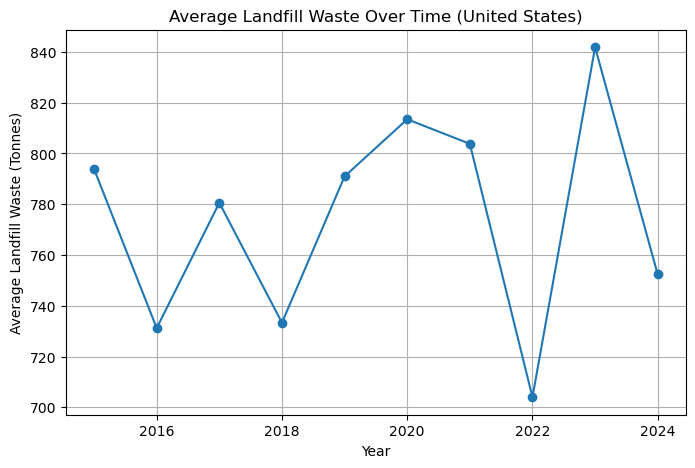

In [2]:
us_yearly = fashion_us.groupby("Year")["Landfill_Waste_Tonnes"].mean()

plt.figure(figsize=(8,5))
plt.plot(us_yearly.index, us_yearly.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Average Landfill Waste (Tonnes)")
plt.title("Average Landfill Waste Over Time (United States)")
plt.grid(True)
plt.show()

This graph shows the average landfill waste in the United States from 2015 to 2024. The data does not follow a consistent upward or downward trend, but instead fluctuates from year to year. While there is a general increase leading up to 2020 and a noticeable spike in 2023, there are also sharp decreases, such as the drop in 2022. These fluctuations suggest that landfill waste is influenced by multiple factors rather than a single steady trend over time. This supports the idea that fast fashion’s impact on landfill waste is complex and may be affected by changes in consumer behavior, economic conditions, and sustainability efforts. As a result, while a regression model can be used to estimate future trends, it may not capture all variations in the data.

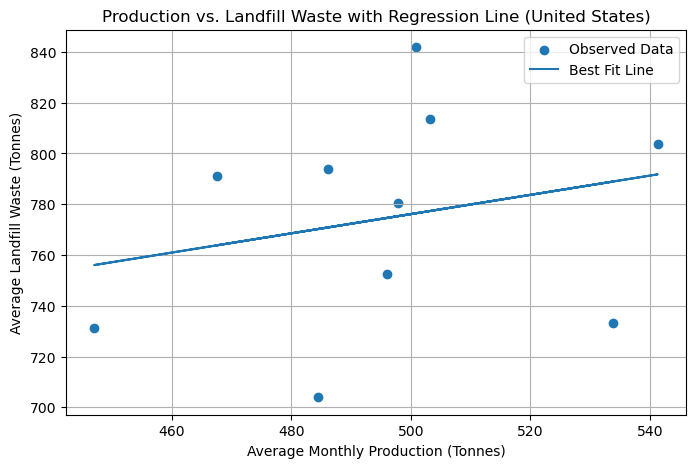

Correlation: 0.24601862699755572


In [8]:
yearly_us = fashion_us.groupby("Year", as_index=False)[
    ["Monthly_Production_Tonnes", "Landfill_Waste_Tonnes"]
].mean()

x = yearly_us["Monthly_Production_Tonnes"]
y = yearly_us["Landfill_Waste_Tonnes"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Observed Data")
plt.plot(x, m*x + b, label="Best Fit Line")
plt.xlabel("Average Monthly Production (Tonnes)")
plt.ylabel("Average Landfill Waste (Tonnes)")
plt.title("Production vs. Landfill Waste with Regression Line (United States)")
plt.grid(True)
plt.legend()
plt.show()

r = np.corrcoef(x, y)[0,1]
print("Correlation:", r)

This scatter plot shows the relationship between average monthly production and landfill waste in the United States, along with a fitted regression line. The upward slope of the line suggests a positive relationship, where higher production is generally associated with higher landfill waste. However, the data points are widely spread around the line, indicating that this relationship is not very strong. This suggests that while production contributes to landfill waste, it does not fully explain the variation observed over time. Other factors, such as consumer behavior, recycling rates, and sustainability efforts, may also influence landfill waste levels.

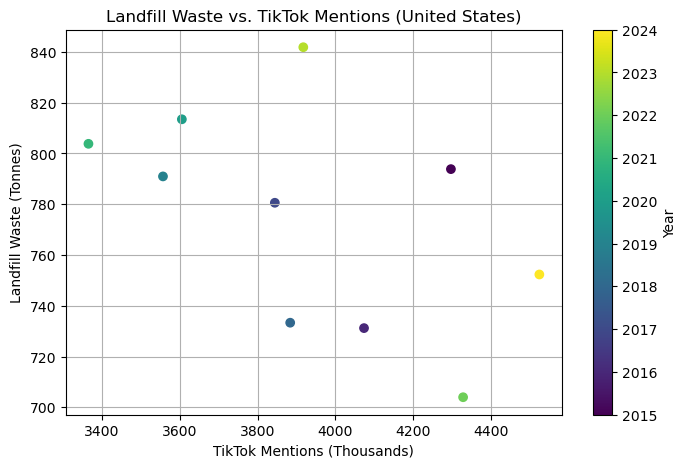

In [9]:
yearly_us = fashion_us.groupby("Year", as_index=False)[
    ["Landfill_Waste_Tonnes", "TikTok_Mentions_Thousands"]
].mean()

plt.figure(figsize=(8,5))

scatter = plt.scatter(
    yearly_us["TikTok_Mentions_Thousands"],
    yearly_us["Landfill_Waste_Tonnes"],
    c=yearly_us["Year"],  # color by year
)

plt.colorbar(scatter, label="Year")
plt.xlabel("TikTok Mentions (Thousands)")
plt.ylabel("Landfill Waste (Tonnes)")
plt.title("Landfill Waste vs. TikTok Mentions (United States)")
plt.grid(True)
plt.show()

This graph shows the relationship between TikTok mentions and landfill waste in the United States, with color representing the progression of time. While there is some variation across years, the pattern does not show a strong or consistent relationship, suggesting that social media attention alone does not directly determine landfill waste levels. However, the inclusion of time highlights how both variables change together across years, supporting the idea that fast fashion trends may play a role but are not the only factor influencing waste.

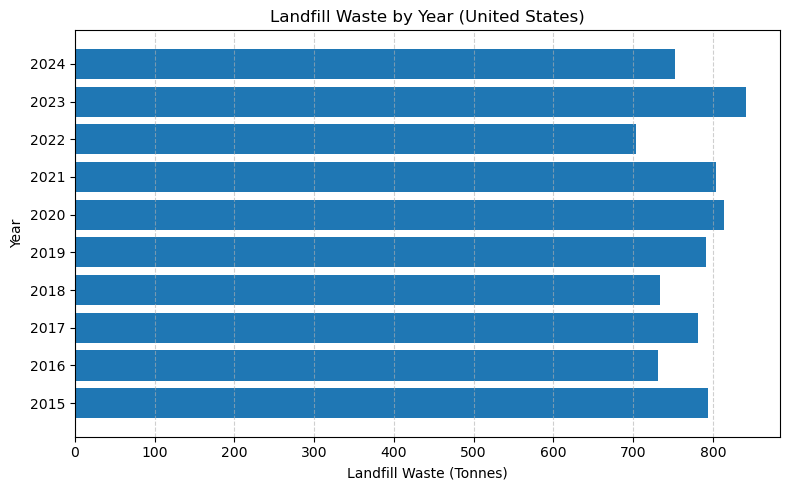

In [13]:
plt.figure(figsize=(8,5))
plt.barh(us_yearly["Year"].astype(str), us_yearly["Landfill_Waste_Tonnes"])

plt.xlabel("Landfill Waste (Tonnes)")
plt.ylabel("Year")
plt.title("Landfill Waste by Year (United States)")
plt.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

A horizontal bar chart would show the same U.S. yearly landfill waste values, but in a format that is often easier to read than a vertical bar chart, especially when you want the labels to look clean and not crowded. In this graph, each bar represents one year, and the length of the bar shows the average landfill waste for that year in the United States. Because the years are listed along the vertical axis and the waste values extend horizontally, the chart makes it easier to compare which years had higher or lower landfill waste without the visual compression that sometimes happens in regular bar charts. This is helpful for your project because it keeps the focus on comparing yearly differences in landfill waste while also giving your notebook more visual variety. The graph would show that some years, such as 2023, have noticeably higher landfill waste, while other years, such as 2022, are lower, reinforcing the idea that landfill waste in the United States changes from year to year rather than following one perfectly steady trend. Overall, this type of graph works well because it is simple, readable, and consistent with your U.S.-only analysis.

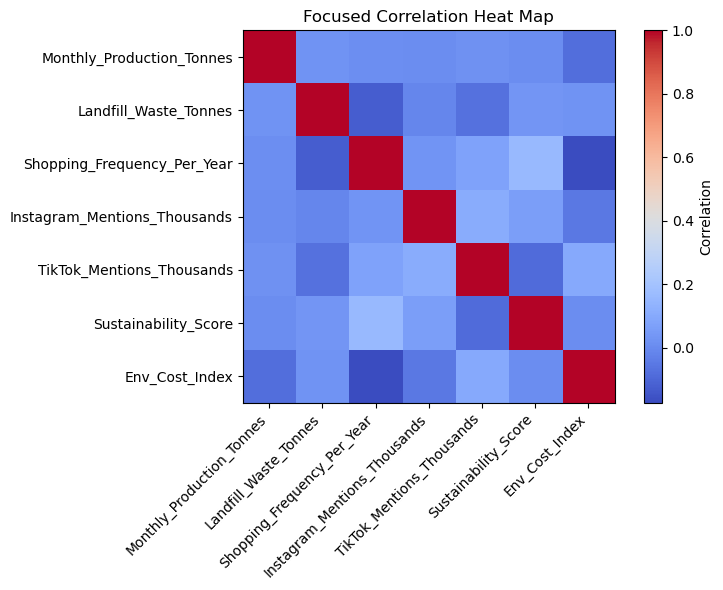

In [15]:
focus_cols = [
    "Monthly_Production_Tonnes",
    "Landfill_Waste_Tonnes",
    "Shopping_Frequency_Per_Year",
    "Instagram_Mentions_Thousands",
    "TikTok_Mentions_Thousands",
    "Sustainability_Score",
    "Env_Cost_Index"
]

corr_matrix = fashion_us[focus_cols].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar(label="Correlation")
plt.xticks(range(len(focus_cols)), focus_cols, rotation=45, ha="right")
plt.yticks(range(len(focus_cols)), focus_cols)
plt.title("Focused Correlation Heat Map")
plt.tight_layout()
plt.show()

This correlation heat map shows the relationships between key variables related to fast fashion and landfill waste in the United States. Each cell represents the strength and direction of the correlation between two variables, with warmer colors indicating stronger positive relationships and cooler colors indicating weaker or negative relationships. Overall, most of the correlations appear to be weak to moderate rather than very strong, suggesting that no single variable fully explains changes in landfill waste. While variables such as production levels, shopping frequency, and social media mentions show some level of association with landfill waste, the relationships are not strong enough to indicate a direct or simple cause. This supports the idea that landfill waste is influenced by multiple interconnected factors, including consumer behavior, industry practices, and environmental conditions. The heat map also highlights that sustainability-related variables do not have a strong negative correlation with landfill waste, suggesting that higher sustainability scores do not necessarily correspond to lower waste levels in a straightforward way. Overall, this graph reinforces that the relationship between fast fashion and landfill waste is complex and cannot be explained by a single variable alone.

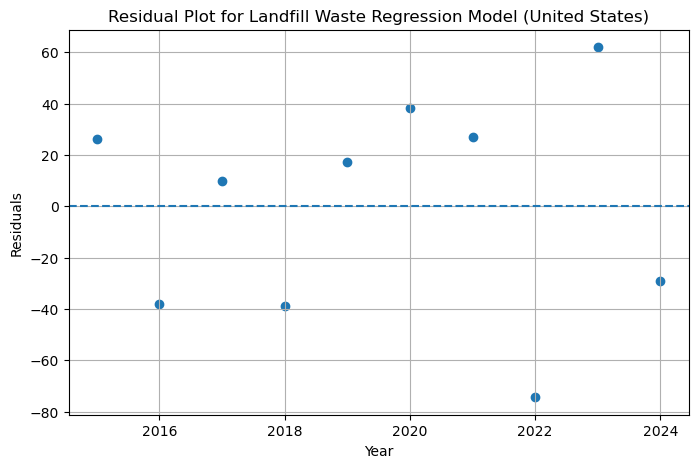

In [16]:
X = yearly_us[["Year"]]
y = yearly_us["Landfill_Waste_Tonnes"]

model = LinearRegression()
model.fit(X, y)

predicted = model.predict(X)
residuals = y - predicted

plt.figure(figsize=(8,5))
plt.scatter(yearly_us["Year"], residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Residuals")
plt.title("Residual Plot for Landfill Waste Regression Model (United States)")
plt.grid(True)
plt.show()

This residual plot shows the difference between the actual landfill waste values and the values predicted by the linear regression model for each year in the United States. The points are scattered above and below zero, which indicates that the model captures some of the overall trend but does not perfectly fit the data. The lack of a clear pattern suggests that a linear model is reasonable, but the variation in residuals shows that landfill waste is influenced by additional factors beyond time alone. This supports the conclusion that while regression can be used to estimate general trends, it does not fully explain all changes in landfill waste.

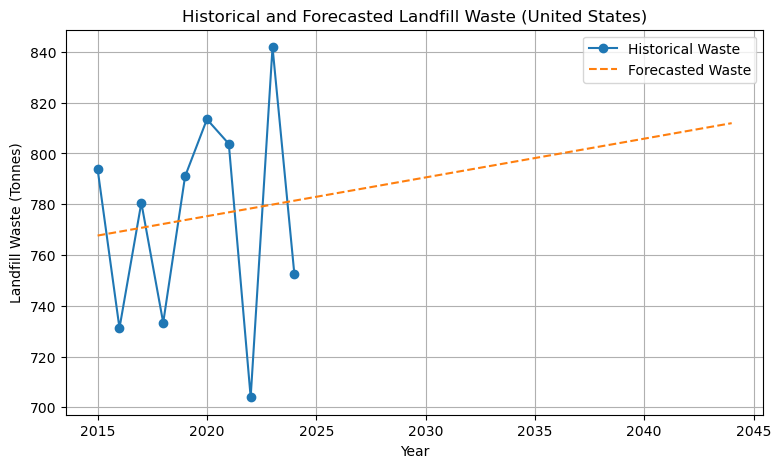

In [17]:
future_years = pd.DataFrame({
    "Year": list(range(yearly_us["Year"].min(), yearly_us["Year"].max() + 21))
})

future_years["Predicted_Landfill_Waste"] = model.predict(future_years[["Year"]])

plt.figure(figsize=(9,5))
plt.plot(yearly_us["Year"], yearly_us["Landfill_Waste_Tonnes"], marker="o", label="Historical Waste")
plt.plot(future_years["Year"], future_years["Predicted_Landfill_Waste"], linestyle="--", label="Forecasted Waste")
plt.xlabel("Year")
plt.ylabel("Landfill Waste (Tonnes)")
plt.title("Historical and Forecasted Landfill Waste (United States)")
plt.grid(True)
plt.legend()
plt.show()

This graph shows both the historical landfill waste in the United States and the predicted values based on a linear regression model. The solid line represents the observed data from 2015 to 2024, while the dashed line shows the model’s forecast for the next 20 years. The forecast follows the general trend identified in the historical data, but it does not capture the year-to-year fluctuations seen in the actual values. This suggests that while the model can provide a general estimate of future landfill waste, it does not fully account for the variability in the data. As a result, the forecast should be interpreted as an approximation rather than an exact prediction, especially since future landfill waste may be influenced by changes in policy, recycling efforts, and consumer behavior.

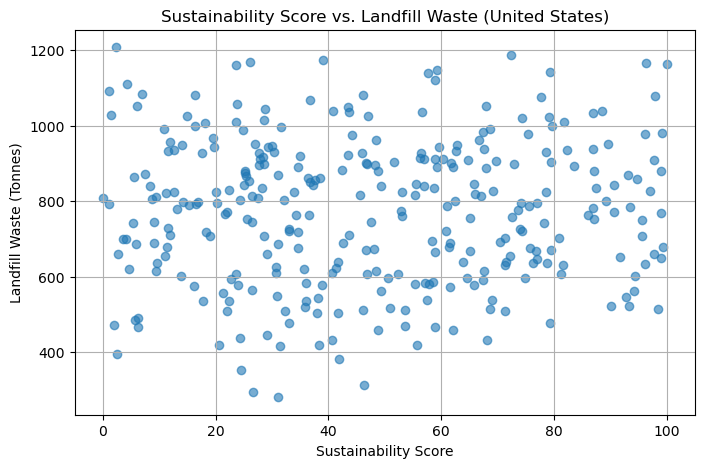

In [19]:
###Sustainability Score vs. Landfill Waste
plt.figure(figsize=(8,5))
plt.scatter(
    fashion_us["Sustainability_Score"],
    fashion_us["Landfill_Waste_Tonnes"],
    alpha=0.6
)
plt.xlabel("Sustainability Score")
plt.ylabel("Landfill Waste (Tonnes)")
plt.title("Sustainability Score vs. Landfill Waste (United States)")
plt.grid(True)
plt.show()

This scatter plot shows the relationship between sustainability scores and landfill waste in the United States. The data points are spread across the graph without forming a strong upward or downward trend, indicating that there is not a clear relationship between the two variables. This suggests that higher sustainability scores do not necessarily correspond to lower landfill waste levels in a simple or direct way. The variation in the data indicates that landfill waste is influenced by multiple factors, and sustainability alone does not fully explain changes in waste. This supports the conclusion that the impact of fast fashion on landfill waste is complex and cannot be understood through a single variable.

### Limitations

This project has several important limitations that affect how the results should be interpreted. First, the dataset covers a limited range of years, which means the forecast is based on a relatively short historical period rather than long-term evidence. Second, some of the variables used in the analysis, such as TikTok mentions, Instagram mentions, and shopping frequency, act only as indirect measures of fast fashion influence and do not fully capture all consumer behavior. In addition, the project relies on yearly averages, which makes it easier to identify broad trends but can also hide important differences within brands, countries, or individual observations. The regression model itself is also limited because it tests simplified linear relationships, while the correlation heat map and residual plot suggest that landfill waste is influenced by multiple factors and may not follow one simple pattern. Finally, the model does not account for policy changes, recycling improvements, economic shifts, or changes in global supply chains, all of which could affect landfill waste in the future. Because of these limits, the results of this project should be viewed as informed estimates based on the available data rather than exact predictions of what will happen over the next 20 years.

In [43]:
print("Year range in dataset:")
print("Start year:", fashion["Year"].min())
print("End year:", fashion["Year"].max())
print("Number of years:", fashion["Year"].nunique())

print("\nMissing values in key project columns:")
limit_cols = [
    "Year",
    "Monthly_Production_Tonnes",
    "Landfill_Waste_Tonnes",
    "Shopping_Frequency_Per_Year",
    "Instagram_Mentions_Thousands",
    "TikTok_Mentions_Thousands",
    "Sustainability_Score",
    "Env_Cost_Index"
]

print(fashion[limit_cols].isnull().sum())

Year range in dataset:
Start year: 2015
End year: 2024
Number of years: 10

Missing values in key project columns:
Year                            0
Monthly_Production_Tonnes       0
Landfill_Waste_Tonnes           0
Shopping_Frequency_Per_Year     0
Instagram_Mentions_Thousands    0
TikTok_Mentions_Thousands       0
Sustainability_Score            0
Env_Cost_Index                  0
dtype: int64


This highlights two important limitations in the dataset. The first part shows the range and number of years included, which helps explain that the forecast is based on a limited historical window. The second part checks for missing values in the main variables used throughout the project. If any of these columns contain missing data, that would mean the analysis may not reflect the complete picture. Including this code in the notebook is helpful because it shows that the limitations were not ignored and that the quality and scope of the dataset were examined directly.

### Discussions and Conclusions

In conclusion, this project applied statistical analysis and visual modeling to investigate the possible relationship between fast fashion consumption trends and landfill waste over time. The combined results of the visualizations suggest that landfill waste is a persistent environmental issue whose behavior cannot be fully explained through a single factor such as production alone. Instead, the graphs indicate that waste patterns are connected to a broader system that includes consumer shopping behavior, trend visibility on social media, sustainability-related measures, and geographic variation. The boxplot highlighted variation within years, the scatter plot and fitted line examined the direct relationship between production and waste, and the dual-axis graph introduced the influence of trend-based media attention. The bar chart comparing countries showed that the issue extends across multiple locations, while the heat map and residual plot demonstrated that the data contains complexity that is not fully captured by a simple regression model. The forecast model provided a useful way to estimate future landfill waste based on the observed historical trend, allowing the project to address its central predictive question. However, the forecast should be interpreted as an informed estimate rather than a precise future outcome, since the model is based on a limited ten-year period and does not account for future policy changes, economic conditions, recycling improvements, or shifts in consumer behavior. Even with these limitations, the project supports the conclusion that fast fashion continues to pose an environmental challenge and that its long-term effects on landfill waste are likely shaped by multiple interacting factors. This makes the issue both statistically interesting and socially important, since reducing landfill waste will likely require attention not only to production levels, but also to consumer habits, trend culture, and sustainability practices. Overall, the analysis suggests that increasing fast fashion activity is associated with rising landfill waste, although the relationship is influenced by multiple interacting factors.

### Works Cited 
Yadav, Khushi. “The True Cost of Fast Fashion Impact.” Kaggle, 14 June 2025, www.kaggle.com/datasets/khushikyad001/the-true-cost-of-fast-fashion-impact. 

“Recycling Economic Information (REI) Report.” EPA, Environmental Protection Agency, www.epa.gov/smm/recycling-economic-information-rei-report. Accessed 20 Apr. 2026. 
